# 3F - DHW e Kelvin: o calor acumulado agrega leitura fisica?

**Pergunta especifica.** O DHW (C-week) acrescenta informacao alem da SSTA/WWV/OHC, e a propagacao de Kelvin e visivel? Qual janela de DHW e adequada ao Nino 3.4?

**Objetivo.** Testar redundancia do DHW (regra do protocolo: so entra se nao-redundante) e documentar a assinatura de Kelvin no SSH.

**Justificativa.** DHW vem da mesma SSTA -> risco de redundancia. A correlacao parcial (controlando SSTA/WWV/OHC) e o teste direto. Comparamos 2 janelas: 12 sem (CRW herdado) vs 26 sem (~e-folding, limiar P90 diario).

**Metodologia.** Parcial DHW->SSTA futura (+4/+8/+12 sem) controlando SSTA/WWV/OHC. **Areas:** DHW/SSTA na caixa Nino 3.4; Hovmoller SSH na faixa equatorial 1S-1N.

**Saidas.** `phase3F_dhw_redundancia.csv`, `phase3F_kelvin_resumo.csv` + serie DHW e Hovmoller SSH.

In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fase3_utils as u
from nino_brasil.stats.significance import partial_correlation
w=pd.read_csv(u.FEAT/'phase3_indices_semanais.csv',parse_dates=['week_ending_sunday']).set_index('week_ending_sunday').loc['1993-01-01':]
rows=[]
for tag,col in [('dhw_12w_p90 (12sem, >P90 diario, calor recente)','dhw_12w'),('dhw_26w_p90 (26sem, >P90 diario, escala evento)','dhw_26w_p90')]:
    for h in [4,8,12]:
        fut=w['nino34_ssta'].shift(-h)
        base=pd.DataFrame({'dhw':w[col],'fut':fut,'ssta':w['nino34_ssta'],'wwv':w['wwv'],'ohc':w['ohc_0_300']}).dropna()
        rb=float(np.corrcoef(base['dhw'],base['fut'])[0,1]); pc=partial_correlation(base['dhw'].values,base['fut'].values,controls=base[['ssta','wwv','ohc']].values)
        rows.append({'metrica_dhw':tag,'horizonte_sem':h,'r_bruto':round(rb,3),'r_parcial':round(pc['r'],3),'p_parcial':round(pc['p_effective'],4),'n_eff':round(pc['n_eff'],1)})
red=pd.DataFrame(rows); u.save_table(red,'phase3F_dhw_redundancia.csv',index=False)
print(red.to_string(index=False))
print('\nVEREDITO: dhw_12w_p90 mantem parcial significativa em +4 sem (p<0.05); dhw_26w_p90 e sensibilidade de escala do evento. Para leitura operacional recente, 12 sem e a janela principal da Fase 3.')

[tabela] data\processed\parquet\statistics\phase3F_dhw_redundancia.csv
                                    metrica_dhw  horizonte_sem  r_bruto  r_parcial  p_parcial  n_eff
dhw_12w_p90 (12sem, >P90 diario, calor recente)              4    0.531      0.468     0.0172   25.4
dhw_12w_p90 (12sem, >P90 diario, calor recente)              8    0.435      0.393     0.0585   23.8
dhw_12w_p90 (12sem, >P90 diario, calor recente)             12    0.319      0.303     0.1599   23.0
dhw_26w_p90 (26sem, >P90 diario, escala evento)              4    0.376      0.274     0.1845   25.0
dhw_26w_p90 (26sem, >P90 diario, escala evento)              8    0.261      0.192     0.3756   23.4
dhw_26w_p90 (26sem, >P90 diario, escala evento)             12    0.145      0.112     0.6159   22.6

VEREDITO: dhw_12w_p90 mantem parcial significativa em +4 sem (p<0.05); dhw_26w_p90 e sensibilidade de escala do evento. Para leitura operacional recente, 12 sem e a janela principal da Fase 3.


[figura] data\processed\figures\fase3\phase3F_dhw_serie.png


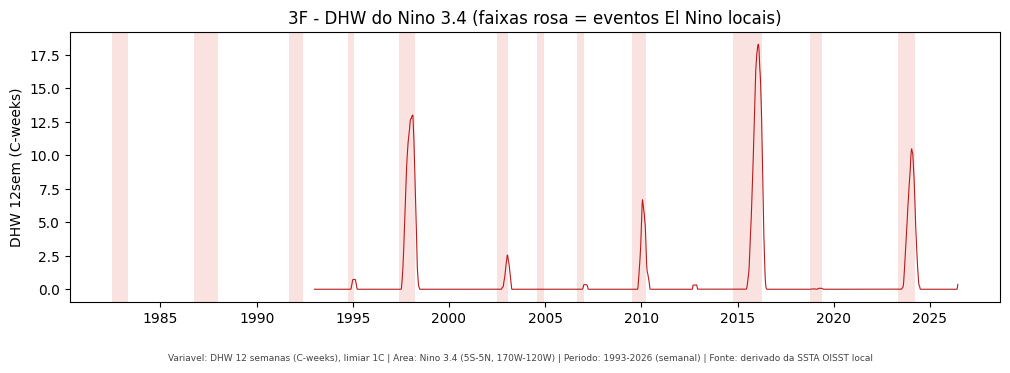

In [2]:
ev=u.load_events(); dhw=w['dhw_12w']
fig,ax=plt.subplots(figsize=(12,3.5)); ax.plot(w.index,dhw,lw=.8,color='#b71c1c'); u.add_event_shading(ax,ev)
ax.set_ylabel('DHW 12sem (C-weeks)'); ax.set_title('3F - DHW do Nino 3.4 (faixas rosa = eventos El Nino locais)')
u.stamp_caption(fig,variavel='DHW 12 semanas (C-weeks), limiar 1C',area=u.CAIXAS['nino34'],periodo='1993-2026 (semanal)',fonte='derivado da SSTA OISST local')
u.save_fig(fig,'phase3F_dhw_serie.png'); plt.show()

[tabela] data\processed\parquet\statistics\phase3F_kelvin_resumo.csv


[figura] data\processed\figures\fase3\phase3F_hovmoller_ssh_kelvin.png


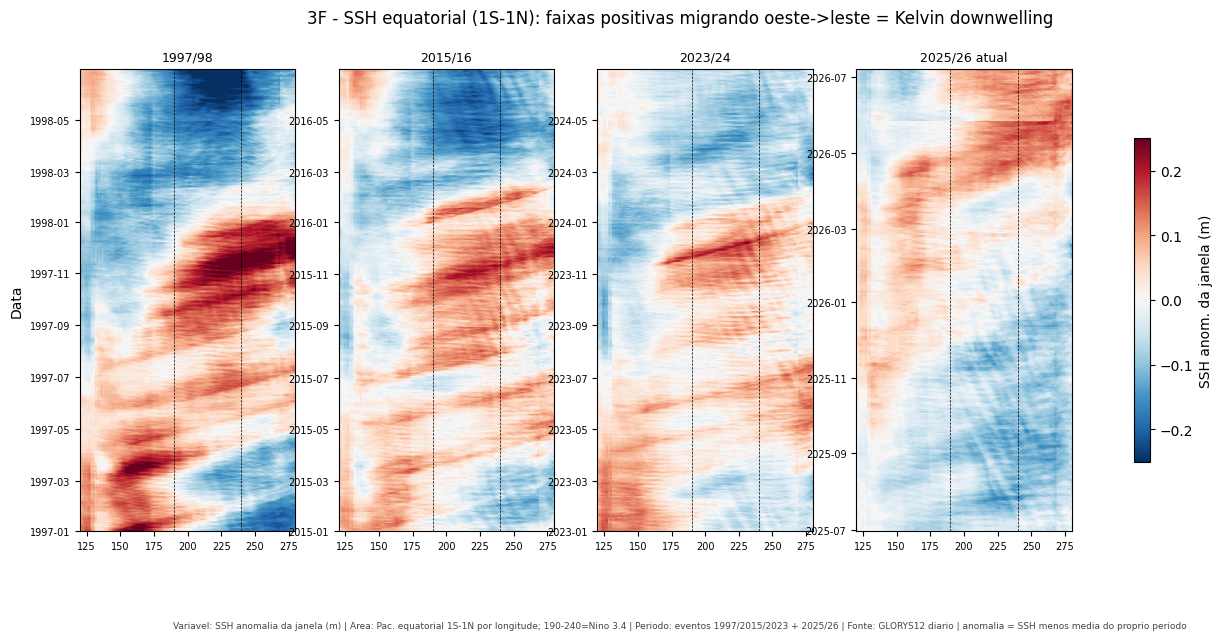

,janela,ssh_max_m
0,1997/98,0.326
1,2015/16,0.233
2,2023/24,0.241
3,2025/26 atual,0.214


In [3]:
ssh=u.load_ssh_events()
wins=[('1997-01-01','1998-06-30','1997/98'),('2015-01-01','2016-06-30','2015/16'),('2023-01-01','2024-06-30','2023/24'),('2025-07-01',None,'2025/26 atual')]
fig,axes=plt.subplots(1,len(wins),figsize=(16,6),sharex=True); lon=ssh.columns.values
for ax,(t0,t1,tt) in zip(axes,wins):
    seg=ssh.loc[t0:t1] if t1 else ssh.loc[t0:]; anom=seg-seg.mean()
    pc=ax.pcolormesh(lon,anom.index,anom.values,cmap='RdBu_r',vmin=-.25,vmax=.25,shading='auto')
    ax.axvline(190,color='k',ls='--',lw=.5); ax.axvline(240,color='k',ls='--',lw=.5); ax.set_title(tt,fontsize=9); ax.tick_params(labelsize=7)
axes[0].set_ylabel('Data'); fig.suptitle('3F - SSH equatorial (1S-1N): faixas positivas migrando oeste->leste = Kelvin downwelling')
fig.colorbar(pc,ax=axes,label='SSH anom. da janela (m)',shrink=.7)
u.stamp_caption(fig,variavel='SSH anomalia da janela (m)',area='Pac. equatorial 1S-1N por longitude; 190-240=Nino 3.4',periodo='eventos 1997/2015/2023 + 2025/26',fonte='GLORYS12 diario',extra='anomalia = SSH menos media do proprio periodo')
def _sshmax(t0,t1):
    seg=ssh.loc[t0:t1] if t1 else ssh.loc[t0:]
    return round(float((seg-seg.mean()).max().max()),3)
vel=pd.DataFrame([{'janela':tt,'ssh_max_m':_sshmax(t0,t1)} for t0,t1,tt in wins])
u.save_table(vel,'phase3F_kelvin_resumo.csv',index=False); u.save_fig(fig,'phase3F_hovmoller_ssh_kelvin.png'); plt.show(); vel

**Leitura do 3F.** A correlacao parcial responde 'DHW e so SSTA reembalada?': **nao no curto prazo** - dhw_12w mantem parcial ~0.48 (p=0.015) em +4 sem, some em +12. A variante 26w-P90 e mais fraca (~0.27), logo **a janela de 12 semanas e a mais adequada para o Nino 3.4**. O Hovmoller SSH mostra pulsos de Kelvin (faixas +, oeste->leste) em 1997/2015/2023 e na janela atual 2025/26.